<a href="https://colab.research.google.com/github/eaHat/acg/blob/main/Midterm_solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Midterm Exam

### General Instructions

- Answer **ALL** mandatory questions. There are also bonus (optional) activities for extra points in case you get stuck in some of the mandatory activities.
- Time Allocated: 3 hours
- This is an individual examination; you are **NOT** allowed to receive help from your peers.
- You are free to use class notes, notebooks and the internet to refer to online documentation and examples, including usage of existing code.

However, note:
- Use of ChatGPT or using any relevant online solutions for this particular use case & data (on Google, Kaggle, GitHub etc.) is **strictly prohibited**.

#### Good Luck!!!


## Python (70%)

###  Load the libraries

Load the necessary libraries.

In [ ]:
# Load the libraries

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

%matplotlib inline
warnings.simplefilter(action='ignore', category=FutureWarning)

### Load the datasets

You have been provided with web scrapped data and you are requested to analyze the Android market. This source of data has enormous potential to drive app-making businesses to success. Actionable insights can be drawn for stakeholders to work on and capture the Android market! Each app (row) has values for category, rating, size, and more!


##### Description of App Dataset columns

- **App** : The name of the app
- **Category** : The category of the app
- **Rating** : The rating of the app
- **Reviews** : The number of reviews of the app
- **Size** : The size of the app
- **Install** : The number of installs of the app
- **Type** : The type of the app (Free/Paid)
- **The price** of the app (0 if it is Free)
- **Content Rating** :The appropiate target audience of the app
- **Genres** : The genre of the app
- **Last Updated** : The date when the app was last updated
- **Current Ver** : The current version of the app
- **Android Ver** : The minimum Android version required to run the app

In [ ]:
# Load the "android.csv" into a new dataframe named "android"
# Preview the first few rows of the data

android = pd.read_csv('./data/android.csv')
android.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [ ]:
# Print the dimensionality of the android DF
android.shape

(10841, 13)

Along with the main dataset, you have been also provided with an additional dataset that contains user reviews for each app, the user sentiment towards this app as well as the sentiment polarity  (a sentiment score) and subjectivity.

In [ ]:
# Load the android_reviews.csv into a new dataframe named "reviews"
# Preview the first few rows of the data

reviews = pd.read_csv('./data/android_reviews.csv')
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [ ]:
# Print the dimensionality of the reviews DF

reviews.shape

(64295, 5)

## Exploring the dataset



#### Sanity checks, data types and missing values

In [ ]:
# Check the data types and associated information in the android DF

android.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [ ]:
# Get the sum of missing values per column in the android DF

pd.DataFrame({'sum_missing': android.isnull().sum()})

,sum_missing
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


In [ ]:
##### What do you observe??? COMMENT here on your findings

### .................................................
### .................................................
### .................................................

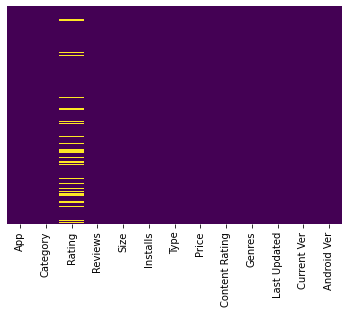

In [ ]:
# Bonus activity - Extra points: Plot the null values heatmap using seaborn

sns.heatmap(android.isnull(), yticklabels=False, cbar=False, cmap='viridis');

#### Fill NAs (Imputing) & Drop NAs

In [ ]:
# Fill the empty values ONLY in the android Rating column using a strategy of your choice.
# Remember to assign back only to the Rating column - not the whole DataFrame
# Justify and comment on your choice of strategy below.

android['Rating'] = android['Rating'].fillna(android['Rating'].median())

In [ ]:
##### Justify and comment on your choice of strategy. Why did you use that?


### .................................................
### .................................................
### .................................................

In [ ]:
# Drop all NAs in the android DF (to remove any remaining cases)
# Note: in case the previous step did not work or you got stuck, this step should help remove all NAs in the DF

android.dropna(inplace=True)

In [ ]:
# Sanity check: ensure that the nulls in the **android** DF have been filled
# Get the sum of missing values per column as before.

# Note: you should see zeros if the activities above were executed correctly

pd.DataFrame({'sum_missing': android.isnull().sum()})

,sum_missing
App,0
Category,0
Rating,0
Reviews,0
Size,0
Installs,0
Type,0
Price,0
Content Rating,0
Genres,0


In [ ]:
# Bonus activity - Extra points

# 1) Fill the NAs in the reviews Sentiment column with the value "Neutral"
# 2) Fill the NAs in the reviews Translated_Review column with the value "-"
# 3) Fill the NAs in the reviews Sentiment_Polarity column with 0
# 4) Fill the NAs in the reviews Sentiment_Subjectivity column with 0


reviews['Sentiment']              = reviews['Sentiment'].fillna("Neutral")
reviews['Translated_Review']      = reviews['Translated_Review'].fillna("-")
reviews['Sentiment_Polarity']     = reviews['Sentiment_Polarity'].fillna(0)
reviews['Sentiment_Subjectivity'] = reviews['Sentiment_Subjectivity'].fillna(0)

In [ ]:
# Bonus activity - Extra points

# Sanity check: ensure that the nulls in the **reviews** DF have been filled
# Get the sum of missing values per column. You should only see zeros

pd.DataFrame({'sum_missing': reviews.isnull().sum()})

,sum_missing
App,0
Translated_Review,0
Sentiment,0
Sentiment_Polarity,0
Sentiment_Subjectivity,0


#### Check for duplicates and drop them

In [ ]:
# Bonus activity (extra points): Get the sum of duplicated values in the android DF

android.duplicated().sum()

483

In [ ]:
# 1) Print the dimensionality of the android DF before the removal of duplicates
# 2) Remove the duplicates in the android DF
# 3) Print the dimensionality of the dataframe android DF after the removal of duplicates

# Sanity check: did your removal go through?
# If the numbers before and after are not different, check your solution again

print(android.shape)
android.drop_duplicates(inplace=True)
print(android.shape)

(10829, 13)
(10346, 13)


In [ ]:
##### What do you observe??? COMMENT here on your findings

### .................................................
### .................................................
### .................................................

####  Unique cases

In [ ]:
# Get the number (count) of unique applications in the android DF

android['App'].nunique()

9648

In [ ]:
# Get the number (count) of unique genres in the android DF

android['Genres'].nunique()

119

In [ ]:
# Get the list of all unique categories from the android dataset

android['Category'].unique()

array(['ART_AND_DESIGN', 'AUTO_AND_VEHICLES', 'BEAUTY',
       'BOOKS_AND_REFERENCE', 'BUSINESS', 'COMICS', 'COMMUNICATION',
       'DATING', 'EDUCATION', 'ENTERTAINMENT', 'EVENTS', 'FINANCE',
       'FOOD_AND_DRINK', 'HEALTH_AND_FITNESS', 'HOUSE_AND_HOME',
       'LIBRARIES_AND_DEMO', 'LIFESTYLE', 'GAME', 'FAMILY', 'MEDICAL',
       'SOCIAL', 'SHOPPING', 'PHOTOGRAPHY', 'SPORTS', 'TRAVEL_AND_LOCAL',
       'TOOLS', 'PERSONALIZATION', 'PRODUCTIVITY', 'PARENTING', 'WEATHER',
       'VIDEO_PLAYERS', 'NEWS_AND_MAGAZINES', 'MAPS_AND_NAVIGATION'],
      dtype=object)

In [ ]:
# Get the list of all unique content rating entries from the android dataset

android['Content Rating'].unique()

array(['Everyone', 'Teen', 'Everyone 10+', 'Mature 17+',
       'Adults only 18+', 'Unrated'], dtype=object)

In [ ]:
# Get the list of all unique type entries from the android dataset

android['Type'].unique()

array(['Free', 'Paid'], dtype=object)

In [ ]:
# Get the list of unique cases of sentiment from the reviews dataset

reviews['Sentiment'].unique()

array(['Positive', 'Neutral', 'Negative'], dtype=object)

### Replacement, casting & describing data

The following code has been given to you to find and replace string values in your data. Execute the code to conduct replacements in the data:

In [ ]:
# Excute/run the code

android['Installs'] = android['Installs'].str.replace(',', '', regex=False)
android['Installs'] = android['Installs'].str.replace('+', '', regex=False)
android['Price']    = android['Price'].str.replace('$', '', regex=False)
android['Size']     = android['Size'].str.replace('k','e+3')
android['Size']     = android['Size'].str.replace('M','e+6')

In [ ]:
# 1. Convert the column Installs to type int. Assign back only to the column Installs
# 2. Convert the column Price to type float. Assign back only to the column Price

android['Installs'] = android['Installs'].astype(int)
android['Price']    = android['Price'].astype(float)

In [ ]:
# Sanity Check. View the data types of the columns. Did your changes go through?

android.dtypes

App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs            int64
Type               object
Price             float64
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

#### Describe the data

In [ ]:
# Describe and get the summary statistics (5 number summary) of the android DF for the numerical column(s)

android.describe()

,Rating,Installs,Price
count,10346.00000,1.034600e+04,10346.000000
mean,4.20377,1.417266e+07,1.031561
std,0.48573,8.028090e+07,16.287252
min,1.00000,0.000000e+00,0.000000
25%,4.10000,1.000000e+03,0.000000
50%,4.30000,1.000000e+05,0.000000
75%,4.50000,1.000000e+06,0.000000
max,5.00000,1.000000e+09,400.000000


In [ ]:
##### What do you understand from this table??? Comment here on some of the values you view and any findings

### .................................................
### .................................................
### .................................................

In [ ]:
# Describe and get the summary of the android DF for categorical cases
# Optional: use .T for transpose to view the results a bit better

android.describe(include = "O").T

,count,unique,top,freq
App,10346,9648,ROBLOX,9
Category,10346,33,FAMILY,1939
Reviews,10346,5999,0,591
Size,10346,457,Varies with device,1525
Type,10346,2,Free,9584
Content Rating,10346,6,Everyone,8372
Genres,10346,119,Tools,840
Last Updated,10346,1376,"August 3, 2018",298
Current Ver,10346,2831,Varies with device,1301
Android Ver,10346,33,4.1 and up,2379


### Filtering (subsetting data)

In [ ]:
# Optional: print the column names to use them during filtering

In [ ]:
# Filter the android DF and return only the entries for the Facebook App
# No need to assign to a new variable

android[android["App"]=="Facebook"]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
2544,Facebook,SOCIAL,4.1,78158306,Varies with device,1000000000,Free,0.0,Teen,Social,"August 3, 2018",Varies with device,Varies with device
3943,Facebook,SOCIAL,4.1,78128208,Varies with device,1000000000,Free,0.0,Teen,Social,"August 3, 2018",Varies with device,Varies with device


In [ ]:
# Filter the android DF where the Rating for apps is higher than 4.8
# No need to assign to a new variable

android[android['Rating'] > 4.8].head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
55,Tickets SDA 2018 and Exam from the State Traff...,AUTO_AND_VEHICLES,4.9,10479,33e+6,100000,Free,0.0,Everyone,Auto & Vehicles,"July 18, 2018",1.7.1,4.0 and up
61,CDL Practice Test 2018 Edition,AUTO_AND_VEHICLES,4.9,7774,17e+6,100000,Free,0.0,Everyone,Auto & Vehicles,"July 3, 2018",1.7,4.2 and up
64,DMV Permit Practice Test 2018 Edition,AUTO_AND_VEHICLES,4.9,6090,27e+6,100000,Free,0.0,Everyone,Auto & Vehicles,"July 3, 2018",1.7,4.2 and up
79,Tickets + PDA 2018 Exam,AUTO_AND_VEHICLES,4.9,197136,38e+6,1000000,Free,0.0,Everyone,Auto & Vehicles,"July 15, 2018",8.31,4.1 and up
99,"ipsy: Makeup, Beauty, and Tips",BEAUTY,4.9,49790,14e+6,1000000,Free,0.0,Everyone,Beauty,"November 9, 2017",2.3.0,4.1 and up


In [ ]:
# Filter the android DF where the Installs are less than 5 AND the category is DATING.
# No need to assign to a new variable

android[(android['Installs']<5) & (android['Category']=='DATING')].head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
649,Healthy Relationships Guide,DATING,4.3,0,8.2e+6,1,Free,0.0,Everyone,Dating,"July 31, 2018",2.0,4.0.3 and up
652,PlusOne,DATING,4.3,0,10e+6,1,Free,0.0,Mature 17+,Dating,"July 17, 2018",1.1.1,4.2 and up


In [ ]:
# Filter the android DF where the Type is Paid AND the Installs are higher than 5000000.
# No need to assign to a new variable

android[(android.Type=="Paid") & (android.Installs > 5000000)].head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
2241,Minecraft,FAMILY,4.5,2376564,Varies with device,10000000,Paid,6.99,Everyone 10+,Arcade;Action & Adventure,"July 24, 2018",1.5.2.1,Varies with device
4034,Hitman Sniper,GAME,4.6,408292,29e+6,10000000,Paid,0.99,Mature 17+,Action,"July 12, 2018",1.7.110758,4.1 and up
4347,Minecraft,FAMILY,4.5,2375336,Varies with device,10000000,Paid,6.99,Everyone 10+,Arcade;Action & Adventure,"July 24, 2018",1.5.2.1,Varies with device


In [ ]:
## Extra activity - bonus points

# Filter the reviews DF where the Sentiment_Polarity is higher than 0.5 AND the Sentiment_Subjectivity
# is lower than 0.1 . No need to assign to a new variable.

reviews[(reviews.Sentiment_Polarity >0.5) & (reviews.Sentiment_Subjectivity < 0.1)].head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
21682,Calorie Counter - EasyFit free,Very useful! I like fact add food math everyth...,Positive,0.761719,0.0
23111,Cameringo Lite. Filters Camera,Useful !!!!❤,Positive,0.732422,0.0


### Combine data

In [ ]:
# Combine the android and reviews datasets into a new DF named "combo"

# Help: It may help to print the column names or preview the first rows of the two datasets
# to check how (what type) and where (which columns) to combine them

combo = pd.merge(android, reviews, how='left',
                 left_on= 'App', right_on='App')
combo.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19e+6,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,NaN,NaN,NaN,NaN
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14e+6,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,A kid's excessive ads. The types ads allowed a...,Negative,-0.250,1.000000
2,Coloring book moana,ART_AND_DESIGN,3.9,967,14e+6,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,It bad >:(,Negative,-0.725,0.833333
3,Coloring book moana,ART_AND_DESIGN,3.9,967,14e+6,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,like,Neutral,0.000,0.000000
4,Coloring book moana,ART_AND_DESIGN,3.9,967,14e+6,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,-,Neutral,0.000,0.000000


In [ ]:
# Print the dimensionality of "combo"

combo.shape

(109224, 17)

In [ ]:
##### COMMENT here (1) on the function you have used (and esp. WHY you have used this function),
##### (2) the type of merge (how) you have performed (and esp. WHY you have used this type of join),
##### (3) the outcome you observe (the dimensionality of the data especially and WHY).
##### I am interested in the logic behind your decision.

### .................................................
### .................................................
### .................................................

### EDA


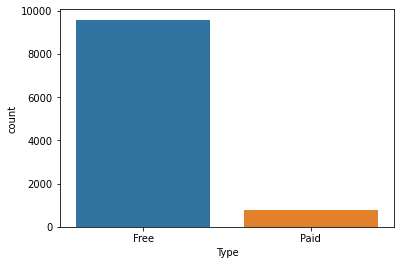

In [ ]:
# Use the seaborn countplot() to visualise the counts (of apps) for each Type in the android DF

sns.countplot(x='Type', data=android)
plt.show();

In [ ]:
##### COMMENT here on the findings of the plot

### .................................................
### .................................................

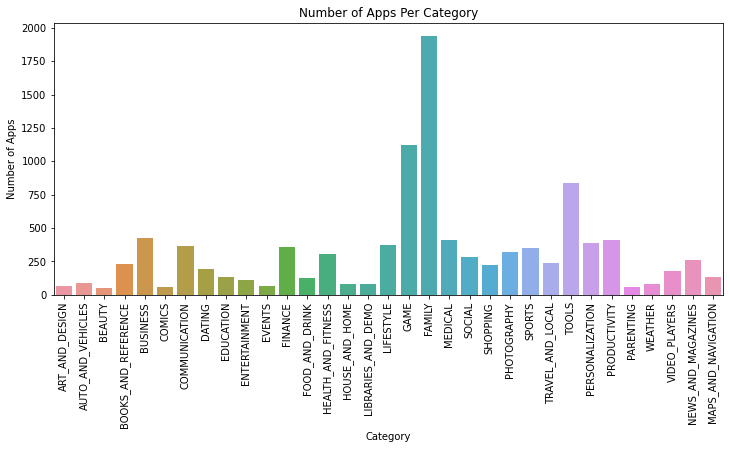

In [ ]:
# Use the seaborn countplot() to visualise the counts (of apps) for each Category in the android DF

# Optional: set the figure size to figsize=(12, 5)
# Optional: set the title to 'Number of Apps Per Category'
# Optional: set the y axis label to 'Number of Apps'
# Optional: set the x axis tick rotation to 90

plt.figure(figsize=(12, 5))
sns.countplot(x='Category', data=android)
plt.title('Number of Apps Per Category')
plt.xticks(rotation=90)
plt.ylabel('Number of Apps')
plt.show();

In [ ]:
##### COMMENT here on the findings of the plot. What do you observe? What are the most popular categories?

### .................................................
### .................................................

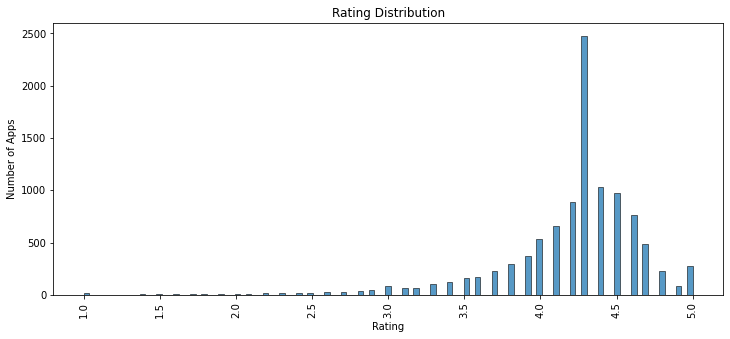

In [ ]:
# Use the seaborn histplot() or countplot() to visualise the distribution of Rating in the android DF.

# Optional: set the figure size to figsize=(12, 5)
# Optional: set the title to 'Rating Distribution'
# Optional: set the y axis label to 'Number of Apps'
# Optional: set the x axis tick rotation to 90

plt.figure(figsize=(12, 5))
sns.histplot(x='Rating', data=android)
plt.title('Rating Distribution')
plt.xticks(rotation=90)
plt.ylabel('Number of Apps')
plt.show()

In [ ]:
##### COMMENT briefly on the findings of the plot. What do you observe?

### .................................................
### .................................................

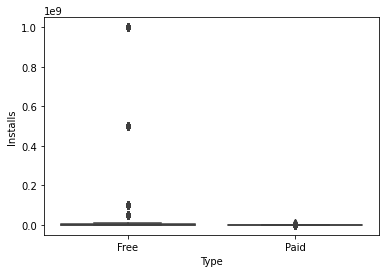

In [ ]:
# Use the seaborn boxplot() to visualise and compare the Installs for each Type in the android DF

sns.boxplot(x = 'Type', y = 'Installs', data = android);

In [ ]:
##### COMMENT briefly here on the findings of the plot. What can you immediately infer from the plot?

### .................................................
### .................................................

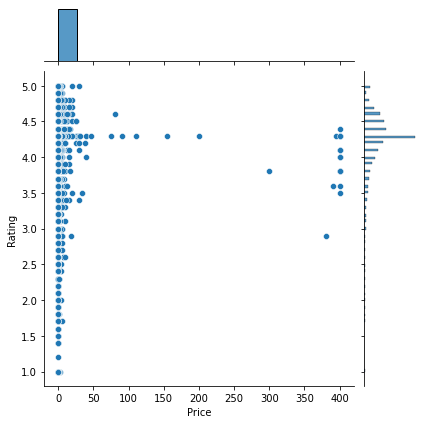

In [ ]:
## Extra activity - bonus points

## Create a seaborn jointplot() to plot the Price against the Rating
## Explain briefly any findings

sns.jointplot(x = android["Price"], y = android["Rating"]);

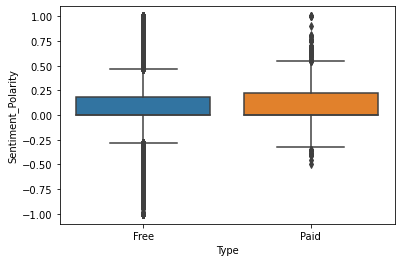

In [ ]:
## Extra activity - bonus points

# Polarity refers to the overall sentiment. This polarity can be expressed as a numerical rating known
# as a “sentiment score”. With that in mind, what can you infer about the boxplot above?
# Can you make some comparisons? Remember what type of information the boxplot "carries".
# Use the seaborn boxplot() to visualise the Sentiment Polarity for each Type in the **combo** DF (from the join)

sns.boxplot(x = 'Type', y = 'Sentiment_Polarity', data = combo);

### Sorting & GroupBy

In [ ]:
# Sort in order to find the *top* android apps based on the number of installations

android.sort_values(by=['Installs'], ascending=False).head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
336,WhatsApp Messenger,COMMUNICATION,4.4,69119316,Varies with device,1000000000,Free,0.0,Everyone,Communication,"August 3, 2018",Varies with device,Varies with device
2554,Google+,SOCIAL,4.2,4831125,Varies with device,1000000000,Free,0.0,Teen,Social,"July 26, 2018",Varies with device,Varies with device
3127,Google Street View,TRAVEL_AND_LOCAL,4.2,2129689,Varies with device,1000000000,Free,0.0,Everyone,Travel & Local,"August 6, 2018",Varies with device,Varies with device
3816,Google News,NEWS_AND_MAGAZINES,3.9,877643,13e+6,1000000000,Free,0.0,Teen,News & Magazines,"August 1, 2018",5.2.0,4.4 and up
3223,Maps - Navigate & Explore,TRAVEL_AND_LOCAL,4.3,9235373,Varies with device,1000000000,Free,0.0,Everyone,Travel & Local,"July 31, 2018",Varies with device,Varies with device


In [ ]:
# Sort in order to find the *worst* android apps based on Ratings. Sort also the Apps alphabetically
# in addition to the Ratings.

android.sort_values(by=['Rating', 'App'], ascending=[True, True]).head(5)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
6319,BJ Bridge Standard American 2018,GAME,1.0,1,4.9e+6,1000,Free,0.0,Everyone,Card,"May 21, 2018",6.2-sayc,4.0 and up
7144,CB Mobile Biz,FINANCE,1.0,3,8.4e+6,500,Free,0.0,Everyone,Finance,"February 22, 2016",4.4.1255,4.0 and up
7427,CJ DVD Rentals,COMMUNICATION,1.0,5,13e+6,100,Free,0.0,Everyone,Communication,"October 6, 2017",1.0,4.1 and up
7806,CR Magazine,BUSINESS,1.0,1,7.8e+6,100,Free,0.0,Everyone,Business,"July 23, 2014",2.4.2,2.3.3 and up
5151,Clarksburg AH,MEDICAL,1.0,1,28e+6,50,Free,0.0,Everyone,Medical,"May 1, 2017",300000.0.81,4.0.3 and up


In [ ]:
# What is the count of Apps per each Category? Find the counts for each case then sort them in a decreasing order

android.groupby('Category')['App'].count().sort_values(ascending=False).head(3)

Category
FAMILY    1939
GAME      1121
TOOLS      841
Name: App, dtype: int64

In [ ]:
##### What are the top 3 Categories? Comment on your findings

### .................................................
### .................................................
### .................................................

In [ ]:
# What is the average Rating for each Category? Find the avg for each case then sort in a decreasing order

android.groupby(["Category"])["Rating"].mean().sort_values(ascending=False).head(3)

Category
EVENTS            4.395313
EDUCATION         4.375385
ART_AND_DESIGN    4.373437
Name: Rating, dtype: float64

In [ ]:
##### What are the top 3 Categories based on the average Rating? Comment on your findings

### .................................................
### .................................................
### .................................................

In [ ]:
#  What is the count of apps for each category and type combination? Sort them in a decreasing order

android.groupby(['Category','Type'])['App'].count().sort_values(ascending=False)

Category            Type
FAMILY              Free    1753
GAME                Free    1038
TOOLS               Free     764
BUSINESS            Free     415
PRODUCTIVITY        Free     379
                            ... 
FOOD_AND_DRINK      Paid       2
PARENTING           Paid       2
NEWS_AND_MAGAZINES  Paid       2
EVENTS              Paid       1
LIBRARIES_AND_DEMO  Paid       1
Name: App, Length: 63, dtype: int64

In [ ]:
##### What are 3 of the worst cases? Are they paid or free? Comment on your findings

### .................................................
### .................................................
### .................................................

In [ ]:
# Bonus Activity - Extra points: What is the count per sentiment and category in the combo DF?

combo.groupby(["Sentiment", "Category"])['App'].count().sort_values(ascending=False).head()

Sentiment  Category
Positive   GAME        9980
Neutral    GAME        9478
Negative   GAME        6542
Neutral    FAMILY      4171
Positive   FAMILY      3564
Name: App, dtype: int64

In [ ]:
##### Bonus Activity - Extra points:
# What are the top 2 cases per category? What is their sentiment? Comment on your findings

### .................................................
### .................................................
### .................................................

## SQL (30%)

As with previous SQL examples in class, feel free to open and use the SQL online editor at https://sqliteonline.com/ . Click on MariaDB -> Click to connect and start writing/testing your solutions.

You can provide your solutions once tested either directly here in your notebook or in a separate file (with the ending ".sql"); if so, remember to zip this file along with your notebook. You are requested to provide answers to the CREATE and SELECT exercises as follows. INSERT INTO statements have also been provided to you to:

- 1) Understand the data types you need to use
- 2) Ensure your data loading has gone through without problems
- 3) Test your SELECT statements

### Create tables

In the following activities, you need to
1. Find the appropriate SQL syntax to generate the following tables **if they don't exist**. The column names for each table have been provided to you.
2. Define the data types **for each column**. As follows, you have also been provided with the INSERT INTO statements that should give you an indication of the data types you need to use while generating the tables.
3. Set any additional constraints (including Primary Keys and Foreign Keys where needed) on the columns and/or table

##### 1) Create the table "Apps" if it doesn't exist. The column names should be:
    - AppId
    - AppName
    - Category
    - Rating
    - Reviews
    - Size
    - Installs
    - Type
    - Price
    - ContentRating
    - LastUpdated
    - CurrentVersion
    - AndroidVersion
Set any constraints.

##### 2) Create the table "UserReviews" if it doesn't exist. The column names should be:
    - ReviewId
    - AppId
    - UserName
    - UserComment
    - UserRating
    - DatePosted
Set any constraints.

##### 3) Create the table "AppGenres" if it doesn't exist. The column names should be:
    - GenreId
    - AppId
    - Genre
Set any constraints.

In [ ]:
### SQL CODE - write the queries one by one (or provide them one by one in an additional .sql file)

CREATE TABLE IF NOT EXISTS Apps (
    AppId INT PRIMARY KEY,
    AppName VARCHAR(255),
    Category VARCHAR(255),
    Rating FLOAT,
    Reviews INT,
    Size VARCHAR(50),
    Installs VARCHAR(50),
    Type VARCHAR(50),
    Price FLOAT,
    ContentRating VARCHAR(50),
    LastUpdated DATE,
    CurrentVersion VARCHAR(50),
    AndroidVersion VARCHAR(50)
);


CREATE TABLE IF NOT EXISTS UserReviews (
    ReviewId INT PRIMARY KEY,
    AppId INT,
    UserName VARCHAR(255),
    UserComment TEXT,
    UserRating INT,
    DatePosted DATE,
    FOREIGN KEY (AppId) REFERENCES Apps(AppId)
);

CREATE TABLE IF NOT EXISTS AppGenres (
    GenreId INT PRIMARY KEY,
    AppId INT,
    Genre VARCHAR(255),
    FOREIGN KEY (AppId) REFERENCES Apps(AppId)
);

In [ ]:
##### Comment here on what Foreign Keys you have set, in which tables and why

### .................................................
### .................................................
### .................................................

### INSERT INTO

You have been provided with the following dummy data. You can copy/paste them and execute them in your online editor.

### SELECT QUERIES

#### Simple queries

1. Select from each table
    - a) Select all from the Apps table
    - b) Select all from the UserReviews table
    - c) Select all from the AppGenres table
    - Do you view the results? Have your INSERT INTO statements gone through correctly?
2. Select the app names and rating from the Apps table
3. Select all **unique** genres from AppGenres. Sort them alphabetically.
4. Select apps that **contain** the word 'App' in their name
5. Select apps that **begin** with the word 'Sub' in their name
6. Select user reviews that **contain** the word 'awesome'

In [ ]:
### SQL CODE - write the queries one by one (or provide them one by one in an additional .sql file)

SELECT * FROM Apps;
SELECT * from UserReviews;
SELECT * from AppGenres;

SELECT AppName, Rating FROM Apps;


SELECT DISTINCT Genre FROM AppGenres ORDER BY Genre;


SELECT * FROM Apps
WHERE AppName LIKE '%App%';


SELECT * FROM Apps
WHERE AppName LIKE 'Sub%';


SELECT * FROM UserReviews
WHERE UserComment LIKE '%awesome%';


#### JOIN queries

7. Select the AppName and Rating along with the respective UserName and UserComment only for cases where there is a comment provided for an app.
8. Select the AppName and their associated Genre even if one is not available

In [ ]:
### SQL CODE - write the queries one by one (or provide them one by one in an additional .sql file)


SELECT ai.AppName, ai.Rating, ur.UserName, ur.UserComment
FROM Apps ai
INNER JOIN UserReviews ur ON ai.AppId = ur.AppId;


SELECT ai.AppName, ag.Genre
FROM Apps ai
LEFT JOIN AppGenres ag ON ai.AppId = ag.AppId;

In [ ]:
##### For both JOINs explain how (what type of merge you would apply in each case) and why!

### Case 7
### .................................................
### .................................................
### .................................................


### Case 8
### .................................................
### .................................................
### .................................................

#### GROUP BY and Aggregation Functions

9. Select the Genre and the Genre Counts (rename it using an alias). Order by Genre Count (Descending)
10. Select the Genres, the count (rename it using an alias) and the average rating (rename it using an alias) for each genre, and keep only the cases with a genre count of 1. Sort the results in an alphabetical order based on the Genre name.  

In [ ]:
### SQL CODE - write the queries one by one (or provide them one by one in an additional .sql file)

SELECT ag.Genre, COUNT(ag.Genre) AS GenreCount
FROM AppGenres ag
GROUP BY ag.Genre
ORDER BY GenreCount DESC;


SELECT ag.Genre, COUNT(ag.AppId) AS AppCount, AVG(ai.Rating) AS AvgRating
FROM AppGenres ag
JOIN Apps ai ON ag.AppId = ai.AppId
GROUP BY ag.Genre
HAVING AppCount =1
ORDER BY AvgRating DESC;


In [ ]:
##### For the questions above comment on your process

### Case 10
### .................................................
### .................................................
### .................................................


### Case 11
### .................................................
### .................................................
### .................................................